<a href="https://colab.research.google.com/github/gilIolgenblum/CrowdingModeWorkshop/blob/main/tutorials/solutions/E1_forward_simulation_solution.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Exercise 1 — Solution: Forward Simulation

This exercise tests your understanding of the `crowding` package API for **forward (simulation) mode**.  
You will build models from scratch using new protein-cosolute pairs not seen in the tutorials.

> **Note:** All cosolute parameters below are taken from published experimental measurements.

Work through each task in order. Use what you learned in tutorials 00–01.

> ⚠️ **This is the solution notebook.** Students should attempt the exercises independently first.

In [1]:
import os
import sys

# Check if we are running in Google Colab
if 'google.colab' in str(get_ipython()):
    # Clone the repository to get the data files
    !git clone https://github.com/gilIolgenblum/CrowdingModeWorkshop.git
    # Change the working directory to the repository root
    os.chdir('/content/CrowdingModeWorkshop')
    # Install the package dependencies
    !pip install -e .

    # TELL PYTHON WHERE THE SOURCE FOLDER IS
    sys.path.append('/content/CrowdingModeWorkshop/src')

In [2]:
import crowding as cr
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

---
## Task A1 — Build a Model from Scratch

**System:** AQ16 protein in Sucrose solution.

Parameters:
- **AQ16:** SASA = 242.6 Å²
- **Sucrose:** $\nu = 11.9$, $\chi = 0.452$, $\chi_{TS} = -0.854$
- Set `eps = 0`, `epsTS = 0` (no soft interaction for now)
- Use `phiC_max=0.20` and `dphiC=0.001`

**Steps:**
1. Create a `cr.Protein` and a `cr.Cosolute`.
2. Build and solve a `cr.CrowdingModel`.
3. Print the predicted **$\Delta\Delta G^0$** (in kJ/mol) at **$\phi = 0.10$**.

*Hint: `model.phiC` contains the volume fraction array and `model.ddA_kj` contains the $\Delta\Delta G^0$ array.*

In [2]:
# Define Protein (AQ16)
AQ16 = cr.Protein(SASA=242.6)

# Define Sucrose Cosolute
sucrose = cr.Cosolute(nu=11.9, chi=0.452, chiTS=-0.854)

# Build and solve the model
model_sucrose = cr.CrowdingModel(
    protein=AQ16,
    cosolute=sucrose,
    eps=0.0, epsTS=0.0,
    phiC_max=0.20, dphiC=0.001
)
model_sucrose.solve_equil()

# Extract ΔΔG⁰ at φ = 0.10
idx = np.argmin(np.abs(model_sucrose.phiC - 0.10))
ddG_at_010 = model_sucrose.ddA_kj[idx]
print(f"ΔΔG⁰ at φ=0.10: {ddG_at_010:.4f} kJ/mol")

ΔΔG⁰ at φ=0.10: -0.4498 kJ/mol


---
## Task A2 — Compare Two Cosolutes

**System:** AQ16 in Sucrose vs. AQ16 in Glycerol.

Glycerol parameters: $\nu = 2.479$, $\chi = 0.233$, $\chi_{TS} = -0.480$

**Steps:**
1. Reuse your Sucrose model from Task A1.
2. Create a second `cr.CrowdingModel` for AQ16 + Glycerol (same `eps=0`).
3. Plot **$\Delta\Delta G^0$ vs $\phi$** for **both** cosolutes on the **same axes** with a legend.

**Question (answer below):** Which cosolute stabilizes AQ16 more at $\phi = 0.10$? explain the result!


*Hint: try plotting $\Delta\Delta G^0$ for other units of concentration.*

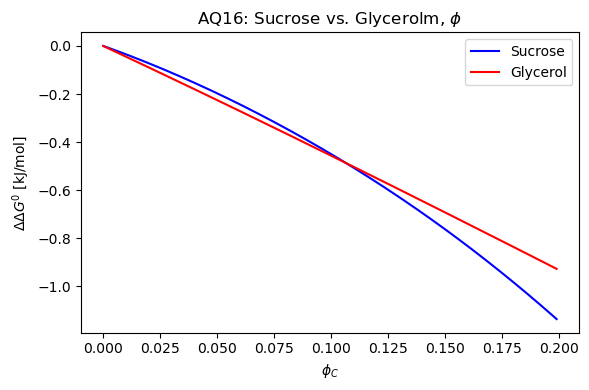

Sucrose  ΔΔG⁰ at φ=0.10: -0.4498 kJ/mol
Glycerol ΔΔG⁰ at φ=0.10: -0.4564 kJ/mol


In [3]:
# Glycerol cosolute
glycerol = cr.Cosolute(nu=2.479, chi=0.233, chiTS=-0.480)
model_glycerol = cr.CrowdingModel(
    protein=AQ16, cosolute=glycerol,
    eps=0.0, epsTS=0.0,
    phiC_max=0.20, dphiC=0.001
)
model_glycerol.solve_equil()

# Plot comparison
fig, ax = plt.subplots(figsize=(6, 4))
ax.plot(model_sucrose.phiC, model_sucrose.ddA_kj, 'b', label="Sucrose")
ax.plot(model_glycerol.phiC, model_glycerol.ddA_kj, 'r', label="Glycerol")
ax.set_xlabel(r"$\phi_C$")
ax.set_ylabel(r"$\Delta\Delta G^0$ [kJ/mol]")
ax.legend()
ax.set_title(r"AQ16: Sucrose vs. Glycerolm, $\phi$")
plt.tight_layout()
plt.show()

# At phi=0.10
idx = np.argmin(np.abs(model_sucrose.phiC - 0.10))
print(f"Sucrose  ΔΔG⁰ at φ=0.10: {model_sucrose.ddA_kj[idx]:.4f} kJ/mol")
print(f"Glycerol ΔΔG⁰ at φ=0.10: {model_glycerol.ddA_kj[idx]:.4f} kJ/mol")

**Answer:** Glycerol and sucrose stabilize AQ16 to approximately the same extent at $\phi = 0.10$ because of a balance between the **number of excluded-volume interactions** and their **strength per cosolute molecule**.

Sucrose has a larger excluded volume than glycerol ($\nu_{\mathrm{suc}} > \nu_{\mathrm{gly}}$), resulting in a stronger excluded-volume effect per cosolute molecule. However, at the same volume fraction ($\phi = 0.10$), the solution contains fewer sucrose molecules than glycerol molecules because each sucrose molecule occupies a larger volume. At $\phi = 0.10$, these two effects approximately compensate, resulting in similar stabilization of AQ16.

This relationship becomes clearer when $\Delta\Delta G^0$ is plotted against **molality**, which reflects the number of cosolute molecules relative to the amount of solvent rather than the volume occupied by the cosolute.


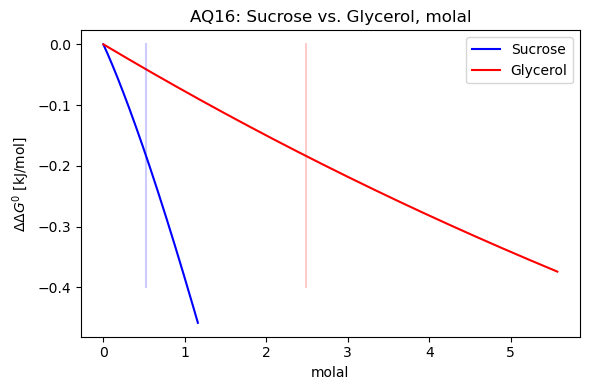

<IPython.core.display.Math object>

In [9]:
# Plot comparison
fig, ax = plt.subplots(figsize=(6, 4))
ax.plot(model_sucrose.molal, model_sucrose.ddA, 'b', label="Sucrose")
ax.plot(model_glycerol.molal, model_glycerol.ddA, 'r', label="Glycerol")
ax.set_xlabel("molal")
ax.set_ylabel(r"$\Delta\Delta G^0$ [kJ/mol]")
idx_suc, idx_gly = np.argmin(np.abs(model_sucrose.phiC - 0.10)), np.argmin(np.abs(model_glycerol.phiC - 0.10))
phi0p1_suc, phi0p1_gly = model_sucrose.molal[idx_suc], model_glycerol.molal[idx_gly]
ax.plot([phi0p1_suc,phi0p1_suc],[0,-0.4],'b',alpha=0.2)
ax.plot([phi0p1_gly,phi0p1_gly],[0,-0.4],'r',alpha=0.2)
ax.legend()
ax.set_title("AQ16: Sucrose vs. Glycerol, molal")
plt.tight_layout()
plt.show()

from IPython.display import display, Math

display(Math(
    rf'''
    \begin{{aligned}}
    \mathrm{{molal}}_\mathrm{{suc}}(\phi=0.10) &\sim {phi0p1_suc:.2f} \\
    \mathrm{{molal}}_\mathrm{{gly}}(\phi=0.10) &\sim {phi0p1_gly:.2f}
    \end{{aligned}}
    '''
))

---
## Task A3 — Sensitivity to $\nu$

**System:** AQ16 + Glycerol (from Task A2).

**Steps:**
1. Create a second Glycerol model with **$\nu$ doubled to 5.0** (all other parameters unchanged).
2. On the **same figure**, plot two subplots:
   - Left: $\Delta\Delta G^0$ for original ($\nu = 2.479$) vs. doubled ($\nu = 5.0$)
   - Right: $T\Delta\Delta S_i^0$ for both models

**Question (answer below):** Does $\Delta\Delta H^0$ change when you double $\nu$? Why or why not?

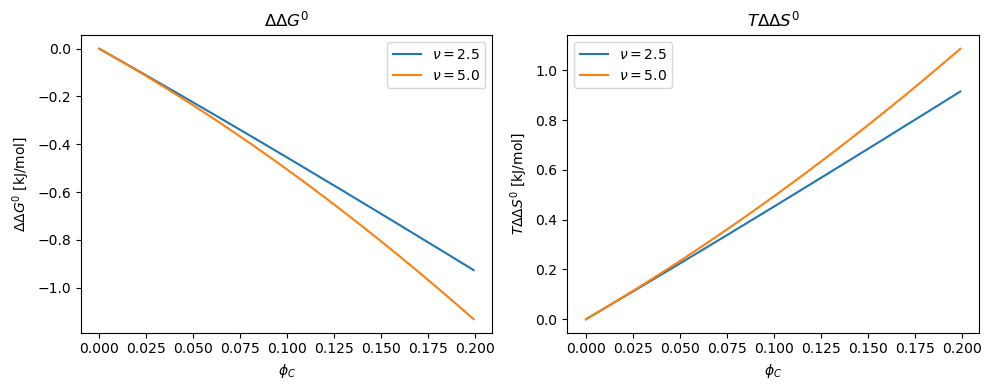

In [5]:
# Glycerol with doubled nu
glycerol_2nu = cr.Cosolute(nu=5.0, chi=glycerol.chi, chiTS=glycerol.chiTS)
model_glycerol_2nu = cr.CrowdingModel(
    protein=AQ16, cosolute=glycerol_2nu,
    eps=0.0, epsTS=0.0,
    phiC_max=0.20, dphiC=0.001
)
model_glycerol_2nu.solve_equil()

fig, axes = plt.subplots(1, 2, figsize=(10, 4))

# ΔΔG⁰
axes[0].plot(model_glycerol.phiC, model_glycerol.ddA_kj, label=r"$\nu=2.5$")
axes[0].plot(model_glycerol_2nu.phiC, model_glycerol_2nu.ddA_kj, label=r"$\nu=5.0$")
axes[0].set_xlabel(r"$\phi_C$")
axes[0].set_ylabel(r"$\Delta\Delta G^0$ [kJ/mol]")
axes[0].legend()
axes[0].set_title(r"$\Delta\Delta G^0$")

# TΔΔSi⁰
axes[1].plot(model_glycerol.phiC, model_glycerol.TddS_kj, label=r"$\nu=2.5$")
axes[1].plot(model_glycerol_2nu.phiC, model_glycerol_2nu.TddS_kj, label=r"$\nu=5.0$")
axes[1].set_xlabel(r"$\phi_C$")
axes[1].set_ylabel(r"$T\Delta\Delta S^0$ [kJ/mol]")
axes[1].legend()
axes[1].set_title(r"$T\Delta\Delta S^0$")

plt.tight_layout()
plt.show()

**Answer:** $\Delta\Delta H^0$ **does** change when $\nu$ is doubled.  
In the Flory-Huggins model, $\nu$ controls the excluded volume (purely entropic) term, which byitself, is non-enthalpic. However, changing $\nu$ impacts the equilbrium between cosolute that are distributed between the protein domain and the bulk, leading to shifts in the number of non-ideal interactions due to greater/lesser exclusion.  

---
## Task A4 — Add a Soft Interaction

**System:** AQ16 + Glycerol, now with `eps = -0.5` and `epsTS = 0.3`.

> **Reminder:** `eps` is the total soft interaction free energy, `epsTS` is its entropic component,  
> and `epsH = eps + epsTS` is the enthalpic component.

**Steps:**
1. Build a new `cr.CrowdingModel` for AQ16 + Glycerol with `eps=-0.5`, `epsTS=0.3`.
2. Use `cr.Plotter` to produce the full thermodynamic panel plot ($\Delta\Delta G^0$, $\Delta\Delta H^0$, and $T\Delta\Delta S_i^0$).

**Question (answer below):** What did adding `eps` change compared to the `eps=0` case in Task A2? Which thermodynamic component is affected?

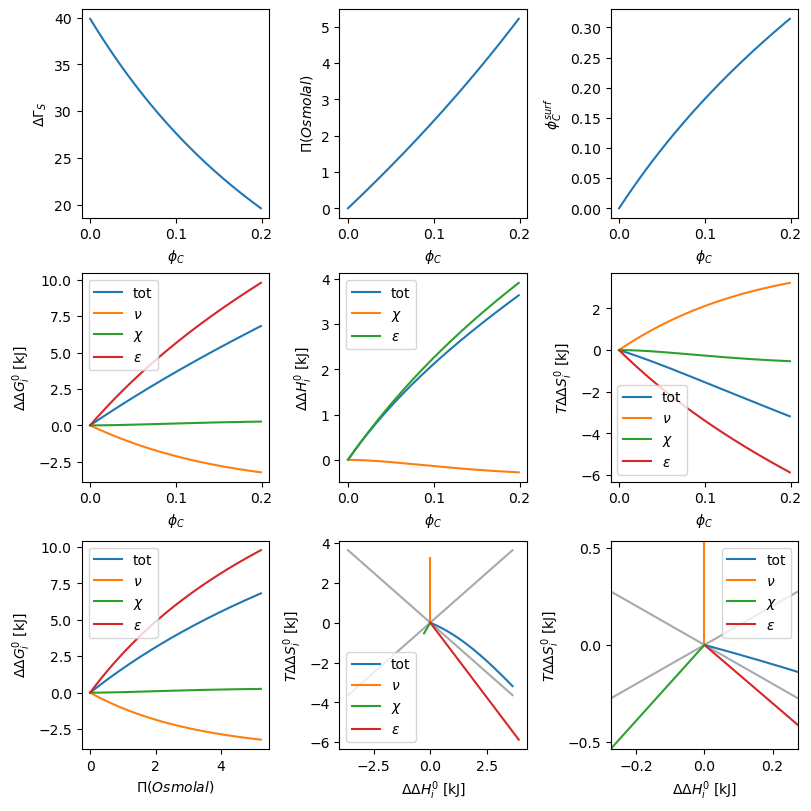

In [6]:
# Glycerol model with soft interaction
model_glycerol_eps = cr.CrowdingModel(
    protein=AQ16, cosolute=glycerol,
    eps=-0.5, epsTS=0.3,
    phiC_max=0.20, dphiC=0.001
)
model_glycerol_eps.solve_equil()

plotter = cr.Plotter(model_glycerol_eps)
fig = plotter.plot_results()
plt.show()

For 'eps=epsTS=0' we get:

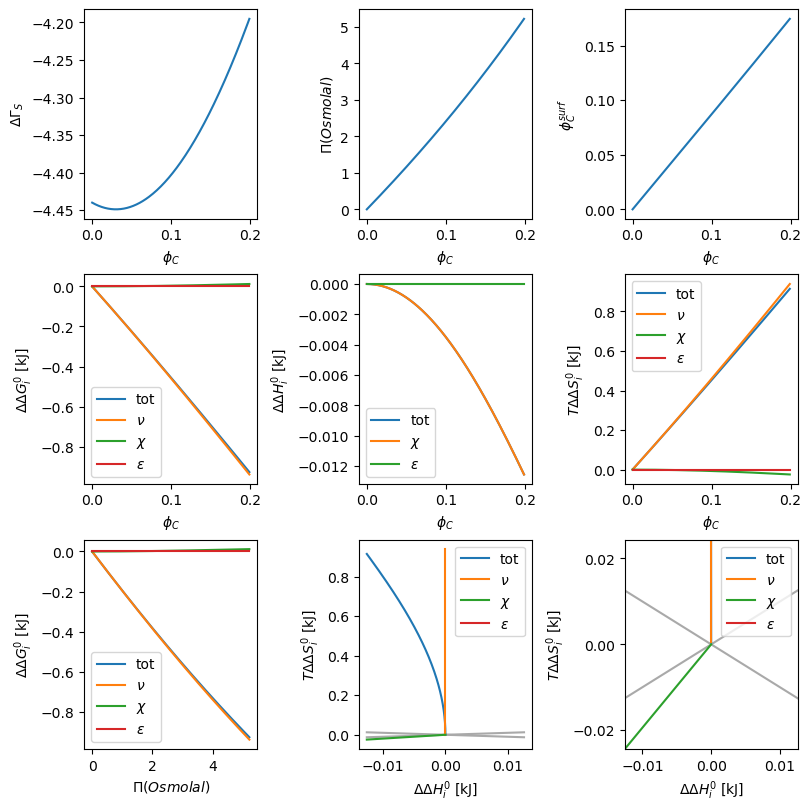

In [8]:
model_glycerol.solve_equil()

plotter = cr.Plotter(model_glycerol)
fig = plotter.plot_results()
plt.show()

**Answer:** Adding `eps = -0.5` changes $\Delta\Delta G^0$ from negative to positive because attractive cosolute–protein interactions preferentially stabilize the unfolded state.

Adding `epsTS = 0.3`, such that `epsH = eps + epsTS = -0.2`, changes $\Delta\Delta H^0$ from $\sim 0$ to strongly positive (destabilizing), while $T\Delta\Delta S^0$ changes from positive (stabilizing) to negative (destabilizing).

This occurs because both the enthalpic and entropic interaction components are attractive, favoring the unfolded state, which has greater solvent-accessible surface area and therefore stronger cosolute–protein interactions than the folded state.

---
## Task A5 — Export Results to CSV

**Steps:**
1. Export the results of your `eps=-0.5` Glycerol model (from Task A4) to a pandas DataFrame using `model.to_pandas()`.
2. Print the first 5 rows.
3. Save the DataFrame to a CSV file named `my_results.csv`.

In [93]:
model_glycerol_eps.to_pandas()
df = model_glycerol_eps.results
df.head()

,phiC,phiCsurf,phiS,phiSsurf,molar,molal,osm,gamma_per_vol,gamma,gammaC_per_vol,...,ddA_chi_kJ,ddA_eps_kJ,ddA_kJ,ddE_chi_kJ,ddE_eps_kJ,ddE_kJ,TddS_nu_kJ,TddS_chi_kJ,TddS_eps_kJ,TddS_kJ
0,0.0001,0.000217,0.9999,0.999783,0.002241,0.002241,0.002241,1.172186,39.862581,-0.000047,...,2.697393e-07,0.006761,0.003985,-2.859468e-07,0.002705,0.002704,0.002777,-5.556861e-07,-0.004057,-0.001281
1,0.0011,0.002385,0.9989,0.997615,0.024652,0.024679,0.024669,1.167777,39.712625,-0.000519,...,3.239336e-05,0.074224,0.043796,-3.433974e-05,0.029690,0.029655,0.030461,-6.673310e-05,-0.044535,-0.014140
2,0.0021,0.004543,0.9979,0.995457,0.047062,0.047161,0.047128,1.163386,39.563313,-0.000988,...,1.171756e-04,0.141414,0.083533,-1.242162e-04,0.056566,0.056441,0.057998,-2.413918e-04,-0.084848,-0.027092
3,0.0031,0.006693,0.9969,0.993307,0.069472,0.069688,0.069616,1.159014,39.414641,-0.001454,...,2.534265e-04,0.208332,0.123198,-2.686538e-04,0.083333,0.083064,0.085388,-5.220803e-04,-0.124999,-0.040134
4,0.0041,0.008834,0.9959,0.991166,0.091883,0.092261,0.092134,1.154661,39.266610,-0.001918,...,4.399749e-04,0.274981,0.162790,-4.664112e-04,0.109992,0.109526,0.112631,-9.063861e-04,-0.164989,-0.053264


In [94]:
#df.to_csv("my_results.csv", index=False)
print("Saved to my_results.csv")

Saved to my_results.csv
